<a href="https://colab.research.google.com/github/visheshchandrakar/Data-ScienceAIML/blob/main/TENSORFLOW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.18.0


In [2]:
mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(10)
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [4]:
predictions = model(x_train[:1]).numpy()
predictions

array([[ 0.22932796, -0.20954713,  0.3730485 ,  0.60325235, -0.00527276,
         0.07778719, -0.35518745, -0.26351678, -0.37284333,  1.2803152 ]],
      dtype=float32)

In [5]:
tf.nn.softmax(predictions).numpy()

array([[0.09542553, 0.06152669, 0.11017464, 0.13869406, 0.07547077,
        0.08200707, 0.0531879 , 0.05829413, 0.05225706, 0.2729622 ]],
      dtype=float32)

In [6]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

In [7]:
loss_fn(y_train[:1], predictions).numpy()

np.float32(2.5009499)

In [8]:
model.compile(optimizer='adam',
              loss=loss_fn,
              metrics=['accuracy'])

In [9]:
model.fit(x_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8598 - loss: 0.4874
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9547 - loss: 0.1524
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9686 - loss: 0.1044
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9739 - loss: 0.0871
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9767 - loss: 0.0747


In [10]:
model.evaluate(x_test,  y_test, verbose=2)

313/313 - 1s - 2ms/step - accuracy: 0.9768 - loss: 0.0742


[0.07424372434616089, 0.9768000245094299]

In [11]:
probability_model = tf.keras.Sequential([
  model,
  tf.keras.layers.Softmax()
])

In [12]:
probability_model(x_test[:5])

<tf.Tensor: shape=(5, 10), dtype=float32, numpy=
array([[8.2017405e-06, 5.7749055e-08, 1.9985968e-05, 2.1116086e-03,
        2.7873440e-10, 4.7123945e-07, 2.3624611e-12, 9.9776447e-01,
        2.2536866e-05, 7.2754119e-05],
       [6.1188268e-09, 1.6905714e-04, 9.9981719e-01, 5.7676385e-07,
        2.7670256e-15, 7.7949007e-06, 2.6084746e-07, 1.2125026e-11,
        5.0757080e-06, 9.5649285e-14],
       [1.5869914e-07, 9.9946421e-01, 8.3992927e-05, 3.9184824e-06,
        3.2041145e-05, 1.1383968e-05, 3.4845054e-06, 2.4135661e-04,
        1.5930577e-04, 1.0746869e-07],
       [9.9977821e-01, 5.4090901e-08, 1.6045937e-05, 4.2148909e-06,
        1.9783661e-06, 3.2511947e-05, 7.0909555e-05, 6.8204310e-05,
        3.6184605e-07, 2.7410304e-05],
       [3.1298873e-06, 2.8932272e-09, 3.7323589e-06, 1.0883517e-06,
        9.8860908e-01, 2.6073044e-06, 3.3419036e-07, 4.0192590e-05,
        3.3867266e-06, 1.1336351e-02]], dtype=float32)>

In [13]:
import tensorflow as tf
normalize = tf.keras.layers.Normalization()

In [14]:
model = tf.keras.models.Sequential([
  normalize, # Add the normalization layer here
  tf.keras.layers.Flatten(input_shape=(28, 28)), # Note: input_shape is not needed here if normalization is the first layer
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(10)
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
import pandas as pd
titanic = pd.read_csv("https://storage.googleapis.com/tf-datasets/titanic/train.csv")
titanic.head()

,survived,sex,age,n_siblings_spouses,parch,fare,class,deck,embark_town,alone
0,0,male,22.0,1,0,7.2500,Third,unknown,Southampton,n
1,1,female,38.0,1,0,71.2833,First,C,Cherbourg,n
2,1,female,26.0,0,0,7.9250,Third,unknown,Southampton,y
3,1,female,35.0,1,0,53.1000,First,C,Southampton,n
4,0,male,28.0,0,0,8.4583,Third,unknown,Queenstown,y


In [18]:
titanic_features = titanic.copy()
titanic_labels = titanic_features.pop('survived')

In [19]:
# Create a symbolic input
input = tf.keras.Input(shape=(), dtype=tf.float32)

# Perform a calculation using the input
result = 2*input + 1

# the result doesn't have a value
result

<KerasTensor shape=(None,), dtype=float32, sparse=False, name=keras_tensor_10>

In [20]:
calc = tf.keras.Model(inputs=input, outputs=result)

In [22]:
import numpy as np
print(calc(np.array([1])).numpy())
print(calc(np.array([2])).numpy())

[3.]
[5.]


In [23]:
inputs = {}

for name, column in titanic_features.items():
  dtype = column.dtype
  if dtype == object:
    dtype = tf.string
  else:
    dtype = tf.float32

  inputs[name] = tf.keras.Input(shape=(1,), name=name, dtype=dtype)

inputs

{'sex': <KerasTensor shape=(None, 1), dtype=string, sparse=False, name=sex>,
 'age': <KerasTensor shape=(None, 1), dtype=float32, sparse=False, name=age>,
 'n_siblings_spouses': <KerasTensor shape=(None, 1), dtype=float32, sparse=False, name=n_siblings_spouses>,
 'parch': <KerasTensor shape=(None, 1), dtype=float32, sparse=False, name=parch>,
 'fare': <KerasTensor shape=(None, 1), dtype=float32, sparse=False, name=fare>,
 'class': <KerasTensor shape=(None, 1), dtype=string, sparse=False, name=class>,
 'deck': <KerasTensor shape=(None, 1), dtype=string, sparse=False, name=deck>,
 'embark_town': <KerasTensor shape=(None, 1), dtype=string, sparse=False, name=embark_town>,
 'alone': <KerasTensor shape=(None, 1), dtype=string, sparse=False, name=alone>}

In [25]:
numeric_inputs = {name:input for name,input in inputs.items()
                  if input.dtype==tf.float32}

x = tf.keras.layers.Concatenate()(list(numeric_inputs.values()))
norm = tf.keras.layers.Normalization()
norm.adapt(np.array(titanic[numeric_inputs.keys()]))
all_numeric_inputs = norm(x)

all_numeric_inputs

<KerasTensor shape=(None, 4), dtype=float32, sparse=False, name=keras_tensor_12>

In [26]:
preprocessed_inputs = [all_numeric_inputs]

In [28]:
for name, input in inputs.items():
  if input.dtype == tf.float32:
    continue

  lookup = tf.keras.layers.StringLookup(vocabulary=np.unique(titanic_features[name]))
  one_hot = tf.keras.layers.CategoryEncoding(num_tokens=lookup.vocabulary_size())

  x = lookup(input)
  x = one_hot(x)
  preprocessed_inputs.append(x)

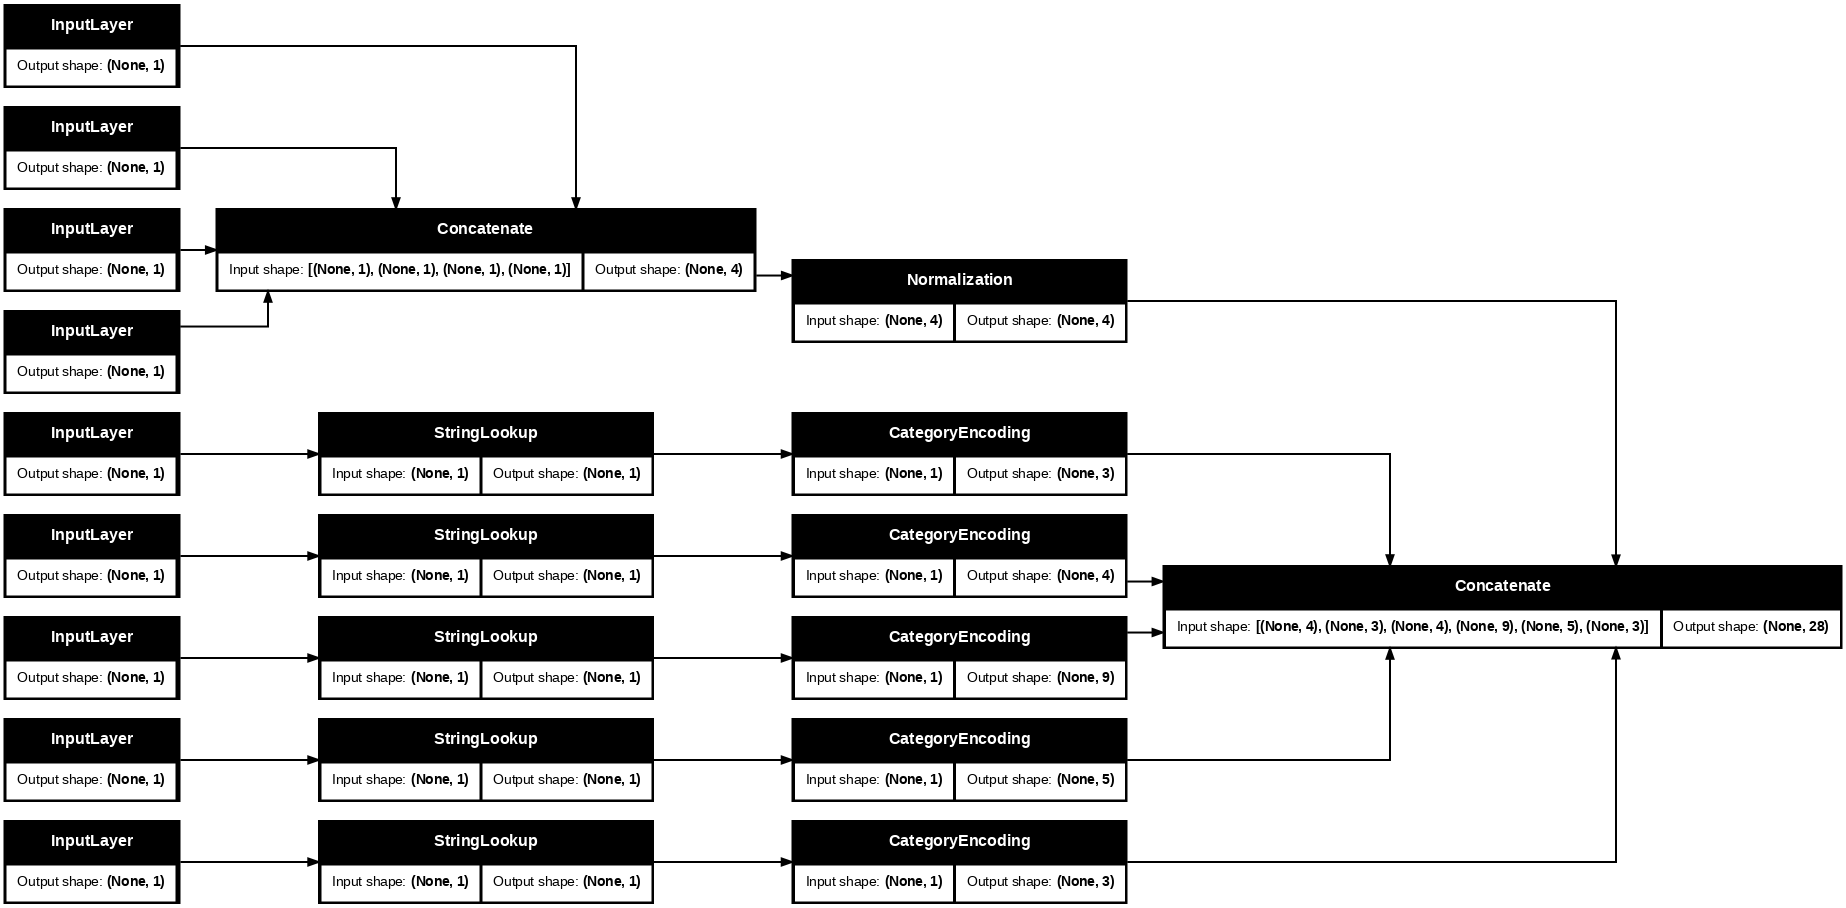

In [30]:
preprocessed_inputs_cat = tf.keras.layers.Concatenate()(preprocessed_inputs)

titanic_preprocessing = tf.keras.Model(inputs, preprocessed_inputs_cat)

tf.keras.utils.plot_model(model = titanic_preprocessing , rankdir="LR", dpi=72, show_shapes=True)

In [31]:
titanic_features_dict = {name: np.array(value)
                         for name, value in titanic_features.items()}

In [32]:
features_dict = {name:values[:1] for name, values in titanic_features_dict.items()}
titanic_preprocessing(features_dict)

<tf.Tensor: shape=(1, 28), dtype=float32, numpy=
array([[-0.6104149 ,  0.39519805, -0.4790527 , -0.4974028 ,  0.        ,
         0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
         1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  1.        ,
         0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
         0.        ,  1.        ,  0.        ]], dtype=float32)>

In [34]:
def titanic_model(preprocessing_head, inputs):
  body = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
  ])

  preprocessed_inputs = preprocessing_head(inputs)
  result = body(preprocessed_inputs)
  model = tf.keras.Model(inputs, result)

  model.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
                optimizer=tf.keras.optimizers.Adam())
  return model

titanic_model = titanic_model(titanic_preprocessing, inputs)

In [35]:
titanic_model.save('test.keras')
reloaded = tf.keras.models.load_model('test.keras')

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [36]:
features_dict = {name:values[:1] for name, values in titanic_features_dict.items()}

before = titanic_model(features_dict)
after = reloaded(features_dict)
assert (before-after)<1e-3
print(before)
print(after)

tf.Tensor([[0.05590949]], shape=(1, 1), dtype=float32)
tf.Tensor([[0.05590949]], shape=(1, 1), dtype=float32)


In [37]:
import itertools

def slices(features):
  for i in itertools.count():
    # For each feature take index `i`
    example = {name:values[i] for name, values in features.items()}
    yield example

In [38]:
for example in slices(titanic_features_dict):
  for name, value in example.items():
    print(f"{name:19s}: {value}")
  break

sex                : male
age                : 22.0
n_siblings_spouses : 1
parch              : 0
fare               : 7.25
class              : Third
deck               : unknown
embark_town        : Southampton
alone              : n


In [39]:
features_ds = tf.data.Dataset.from_tensor_slices(titanic_features_dict)

In [40]:
for example in features_ds:
  for name, value in example.items():
    print(f"{name:19s}: {value}")
  break

sex                : b'male'
age                : 22.0
n_siblings_spouses : 1
parch              : 0
fare               : 7.25
class              : b'Third'
deck               : b'unknown'
embark_town        : b'Southampton'
alone              : b'n'


In [41]:
titanic_ds = tf.data.Dataset.from_tensor_slices((titanic_features_dict, titanic_labels))

In [42]:
titanic_batches = titanic_ds.shuffle(len(titanic_labels)).batch(32)

In [43]:
titanic_model.fit(titanic_batches, epochs=5)

Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6858
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6032 
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5474 
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5407
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4913 


In [44]:
titanic_file_path = tf.keras.utils.get_file("train.csv", "https://storage.googleapis.com/tf-datasets/titanic/train.csv")

30874/30874 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [45]:
titanic_csv_ds = tf.data.experimental.make_csv_dataset(
    titanic_file_path,
    batch_size=5, # Artificially small to make examples easier to show.
    label_name='survived',
    num_epochs=1,
    ignore_errors=True,)

Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.


In [46]:
for batch, label in titanic_csv_ds.take(1):
  for key, value in batch.items():
    print(f"{key:20s}: {value}")
  print()
  print(f"{'label':20s}: {label}")

sex                 : [b'female' b'female' b'male' b'female' b'male']
age                 : [63. 28. 40. 51. 28.]
n_siblings_spouses  : [0 3 0 1 0]
parch               : [0 1 0 0 0]
fare                : [ 9.5875 25.4667 27.7208 77.9583 56.4958]
class               : [b'Third' b'Third' b'First' b'First' b'Third']
deck                : [b'unknown' b'unknown' b'unknown' b'D' b'unknown']
embark_town         : [b'Southampton' b'Southampton' b'Cherbourg' b'Southampton' b'Southampton']
alone               : [b'y' b'n' b'y' b'n' b'y']

label               : [1 0 0 1 0]


In [47]:
traffic_volume_csv_gz = tf.keras.utils.get_file(
    'Metro_Interstate_Traffic_Volume.csv.gz',
    "https://archive.ics.uci.edu/ml/machine-learning-databases/00492/Metro_Interstate_Traffic_Volume.csv.gz",
    cache_dir='.', cache_subdir='traffic')

 294912/Unknown 1s 2us/step

In [48]:
traffic_volume_csv_gz_ds = tf.data.experimental.make_csv_dataset(
    traffic_volume_csv_gz,
    batch_size=256,
    label_name='traffic_volume',
    num_epochs=1,
    compression_type="GZIP")

for batch, label in traffic_volume_csv_gz_ds.take(1):
  for key, value in batch.items():
    print(f"{key:20s}: {value[:5]}")
  print()
  print(f"{'label':20s}: {label[:5]}")

holiday             : [b'None' b'None' b'None' b'None' b'None']
temp                : [271.57 281.64 283.43 293.76 277.61]
rain_1h             : [0. 0. 0. 0. 0.]
snow_1h             : [0. 0. 0. 0. 0.]
clouds_all          : [90 90  1  1 20]
weather_main        : [b'Mist' b'Rain' b'Clear' b'Clear' b'Clouds']
weather_description : [b'mist' b'moderate rain' b'sky is clear' b'sky is clear' b'few clouds']
date_time           : [b'2013-04-13 02:00:00' b'2013-05-02 04:00:00' b'2013-05-07 09:00:00'
 b'2013-04-29 12:00:00' b'2012-11-17 12:00:00']

label               : [ 551  708 5229 4889 4753]


In [49]:
%%time
for i, (batch, label) in enumerate(traffic_volume_csv_gz_ds.repeat(20)):
  if i % 40 == 0:
    print('.', end='')
print()

...............................................................................................
CPU times: user 26.5 s, sys: 3.69 s, total: 30.2 s
Wall time: 41 s


In [50]:
%%time
caching = traffic_volume_csv_gz_ds.cache().shuffle(1000)

for i, (batch, label) in enumerate(caching.shuffle(1000).repeat(20)):
  if i % 40 == 0:
    print('.', end='')
print()

...............................................................................................
CPU times: user 3.18 s, sys: 263 ms, total: 3.44 s
Wall time: 5.13 s


In [51]:
%%time
snapshotting = traffic_volume_csv_gz_ds.snapshot('titanic.tfsnap').shuffle(1000)

for i, (batch, label) in enumerate(snapshotting.shuffle(1000).repeat(20)):
  if i % 40 == 0:
    print('.', end='')
print()

...............................................................................................
CPU times: user 4.31 s, sys: 385 ms, total: 4.7 s
Wall time: 5 s


In [52]:
fonts_zip = tf.keras.utils.get_file(
    'fonts.zip',  "https://archive.ics.uci.edu/ml/machine-learning-databases/00417/fonts.zip",
    cache_dir='.', cache_subdir='fonts',
    extract=True)

158212096/Unknown 8s 0us/step

In [54]:
import pathlib
font_csvs =  sorted(str(p) for p in pathlib.Path('fonts').glob("*.csv"))

font_csvs[:10]

[]

In [55]:
for batch, label in titanic_csv_ds.take(1):
  for key, value in batch.items():
    print(f"{key:20s}: {value}")
  print()
  print(f"{'label':20s}: {label}")

sex                 : [b'female' b'male' b'female' b'male' b'male']
age                 : [44. 18.  3. 47. 32.]
n_siblings_spouses  : [0 0 1 0 0]
parch               : [0 0 2 0 0]
fare                : [27.7208  7.775  41.5792  9.      8.05  ]
class               : [b'First' b'Third' b'Second' b'Third' b'Third']
deck                : [b'B' b'unknown' b'unknown' b'unknown' b'E']
embark_town         : [b'Cherbourg' b'Southampton' b'Cherbourg' b'Southampton' b'Southampton']
alone               : [b'y' b'y' b'n' b'y' b'y']

label               : [1 0 1 0 1]


In [56]:
traffic_volume_csv_gz = tf.keras.utils.get_file(
    'Metro_Interstate_Traffic_Volume.csv.gz',
    "https://archive.ics.uci.edu/ml/machine-learning-databases/00492/Metro_Interstate_Traffic_Volume.csv.gz",
    cache_dir='.', cache_subdir='traffic')

In [57]:
traffic_volume_csv_gz_ds = tf.data.experimental.make_csv_dataset(
    traffic_volume_csv_gz,
    batch_size=256,
    label_name='traffic_volume',
    num_epochs=1,
    compression_type="GZIP")

for batch, label in traffic_volume_csv_gz_ds.take(1):
  for key, value in batch.items():
    print(f"{key:20s}: {value[:5]}")
  print()
  print(f"{'label':20s}: {label[:5]}")

holiday             : [b'None' b'None' b'None' b'None' b'None']
temp                : [298.61 288.17 273.08 259.24 274.19]
rain_1h             : [0. 0. 0. 0. 0.]
snow_1h             : [0. 0. 0. 0. 0.]
clouds_all          : [  0  56   1 100  90]
weather_main        : [b'Clear' b'Mist' b'Clear' b'Clouds' b'Mist']
weather_description : [b'Sky is Clear' b'mist' b'sky is clear' b'overcast clouds' b'mist']
date_time           : [b'2013-07-26 13:00:00' b'2013-08-10 08:00:00' b'2013-03-30 00:00:00'
 b'2013-02-05 02:00:00' b'2013-03-10 06:00:00']

label               : [5583 2792 1092  243  704]


In [58]:
%%time
for i, (batch, label) in enumerate(traffic_volume_csv_gz_ds.repeat(20)):
  if i % 40 == 0:
    print('.', end='')
print()

...............................................................................................
CPU times: user 28.2 s, sys: 3.54 s, total: 31.7 s
Wall time: 41 s


In [59]:
%%time
caching = traffic_volume_csv_gz_ds.cache().shuffle(1000)

for i, (batch, label) in enumerate(caching.shuffle(1000).repeat(20)):
  if i % 40 == 0:
    print('.', end='')
print()

...............................................................................................
CPU times: user 3.09 s, sys: 234 ms, total: 3.33 s
Wall time: 2.76 s


In [60]:
%%time
snapshotting = traffic_volume_csv_gz_ds.snapshot('titanic.tfsnap').shuffle(1000)

for i, (batch, label) in enumerate(snapshotting.shuffle(1000).repeat(20)):
  if i % 40 == 0:
    print('.', end='')
print()

...............................................................................................
CPU times: user 4.06 s, sys: 384 ms, total: 4.44 s
Wall time: 3.72 s


In [61]:
fonts_zip = tf.keras.utils.get_file(
    'fonts.zip',  "https://archive.ics.uci.edu/ml/machine-learning-databases/00417/fonts.zip",
    cache_dir='.', cache_subdir='fonts',
    extract=True)

In [81]:
import pathlib
font_csvs =  sorted(str(p) for p in pathlib.Path('fonts/fonts_extracted').glob("*.csv"))

font_csvs[:10]

['fonts/fonts_extracted/AGENCY.csv',
 'fonts/fonts_extracted/ARIAL.csv',
 'fonts/fonts_extracted/BAITI.csv',
 'fonts/fonts_extracted/BANKGOTHIC.csv',
 'fonts/fonts_extracted/BASKERVILLE.csv',
 'fonts/fonts_extracted/BAUHAUS.csv',
 'fonts/fonts_extracted/BELL.csv',
 'fonts/fonts_extracted/BERLIN.csv',
 'fonts/fonts_extracted/BERNARD.csv',
 'fonts/fonts_extracted/BITSTREAMVERA.csv']

In [63]:
len(font_csvs)

0

In [66]:
fonts_ds = tf.data.experimental.make_csv_dataset(
    file_pattern = "fonts/*.csv",
    batch_size=10, num_epochs=1,
    num_parallel_reads=20,
    shuffle_buffer_size=10000)

In [65]:
import os

# List contents of the 'fonts' directory
print(os.listdir('fonts'))

['fonts.zip', 'fonts_extracted']


In [68]:
fonts_ds = tf.data.experimental.make_csv_dataset(
    file_pattern = "fonts/fonts_extracted/*.csv",
    batch_size=10, num_epochs=1,
    num_parallel_reads=20,
    shuffle_buffer_size=10000)

In [69]:
for features in fonts_ds.take(1):
  for i, (name, value) in enumerate(features.items()):
    if i>15:
      break
    print(f"{name:20s}: {value}")
print('...')
print(f"[total: {len(features)} features]")

font                : [b'SCRIPTB' b'GEORGIA' b'ROMAN' b'ROMAN' b'STENCIL' b'STENCIL' b'GUNPLAY'
 b'SCRIPTB' b'STENCIL' b'TW']
fontVariant         : [b'SCRIPT MT BOLD' b'GEORGIA' b'ROMANT' b'ROMANT' b'STENCIL' b'STENCIL'
 b'GUNPLAY' b'SCRIPT MT BOLD' b'STENCIL' b'TW CEN MT CONDENSED EXTRA BOLD']
m_label             : [ 190  354   62 1095  270  236  347 8776  185  118]
strength            : [0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4]
italic              : [0 0 0 1 1 1 0 0 0 0]
orientation         : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
m_top               : [37 36 46 56 35 24 34 55 36 51]
m_left              : [21 20 27 36 27 24 22 22 26 21]
originalH           : [55 61 44 34 47 57 45 24 27 30]
originalW           : [46 41 39 43 44 35 30 33 13 26]
h                   : [20 20 20 20 20 20 20 20 20 20]
w                   : [20 20 20 20 20 20 20 20 20 20]
r0c0                : [  1 255 199 151   1   1   1   1  67 255]
r0c1                : [  1 255  27 214   1   1   1   1 154 255]
r0c2            

In [70]:
for features in fonts_ds.take(1):
  for i, (name, value) in enumerate(features.items()):
    if i>15:
      break
    print(f"{name:20s}: {value}")
print('...')
print(f"[total: {len(features)} features]")

font                : [b'BAUHAUS' b'ROMANTIC' b'TAHOMA' b'BRITANNIC' b'ROMAN' b'STENCIL'
 b'COPPERPLATE' b'ONYX' b'BRITANNIC' b'JAVANESE']
fontVariant         : [b'BAUHAUS 93' b'ROMANTIC' b'TAHOMA' b'BRITANNIC BOLD' b'ROMANT'
 b'STENCIL' b'COPPERPLATE GOTHIC LIGHT' b'ONYX' b'BRITANNIC BOLD'
 b'JAVANESE TEXT']
m_label             : [   74   201 64502    84   231  9674    84   173   236  8210]
strength            : [0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4]
italic              : [0 0 0 1 0 1 1 1 0 0]
orientation         : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
m_top               : [35 20 44 35 56 35 31 62 34 87]
m_left              : [20 21 23 31 27 28 33 27 23 21]
originalH           : [46 60 57 45 50 47 47  5 46  3]
originalW           : [17 39 79 39 32 34 46 10 15 33]
h                   : [20 20 20 20 20 20 20 20 20 20]
w                   : [20 20 20 20 20 20 20 20 20 20]
r0c0                : [  1   1   1   1   1   1  20   1 111 255]
r0c1                : [  1   1   1 133   1   1 166   1 

In [71]:
import re

def make_images(features):
  image = [None]*400
  new_feats = {}

  for name, value in features.items():
    match = re.match('r(\d+)c(\d+)', name)
    if match:
      image[int(match.group(1))*20+int(match.group(2))] = value
    else:
      new_feats[name] = value

  image = tf.stack(image, axis=0)
  image = tf.reshape(image, [20, 20, -1])
  new_feats['image'] = image

  return new_feats

In [72]:
fonts_image_ds = fonts_ds.map(make_images)

for features in fonts_image_ds.take(1):
  break

/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 63339 (\uf76b) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 63339 (\uf76b) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


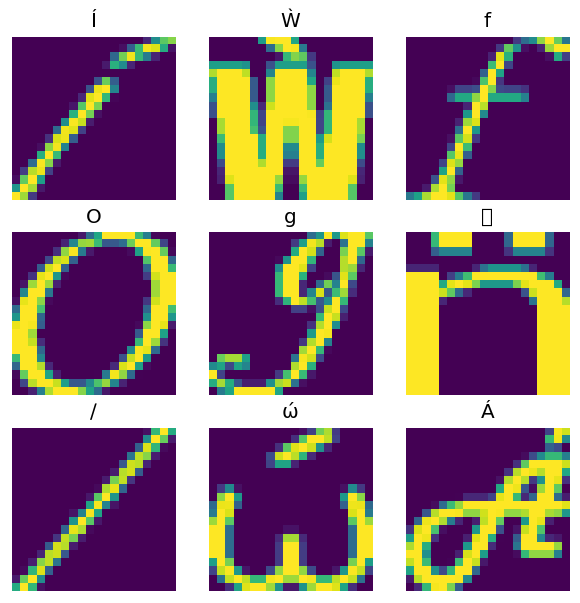

In [73]:
from matplotlib import pyplot as plt

plt.figure(figsize=(6,6), dpi=120)

for n in range(9):
  plt.subplot(3,3,n+1)
  plt.imshow(features['image'][..., n])
  plt.title(chr(features['m_label'][n]))
  plt.axis('off')

In [74]:
text = pathlib.Path(titanic_file_path).read_text()
lines = text.split('\n')[1:-1]

all_strings = [str()]*10
all_strings

['', '', '', '', '', '', '', '', '', '']

In [75]:
features = tf.io.decode_csv(lines, record_defaults=all_strings)

for f in features:
  print(f"type: {f.dtype.name}, shape: {f.shape}")

type: string, shape: (627,)
type: string, shape: (627,)
type: string, shape: (627,)
type: string, shape: (627,)
type: string, shape: (627,)
type: string, shape: (627,)
type: string, shape: (627,)
type: string, shape: (627,)
type: string, shape: (627,)
type: string, shape: (627,)


In [76]:
print(lines[0])

0,male,22.0,1,0,7.25,Third,unknown,Southampton,n


In [77]:
titanic_types = [int(), str(), float(), int(), int(), float(), str(), str(), str(), str()]
titanic_types

[0, '', 0.0, 0, 0, 0.0, '', '', '', '']

In [78]:
features = tf.io.decode_csv(lines, record_defaults=titanic_types)

for f in features:
  print(f"type: {f.dtype.name}, shape: {f.shape}")

type: int32, shape: (627,)
type: string, shape: (627,)
type: float32, shape: (627,)
type: int32, shape: (627,)
type: int32, shape: (627,)
type: float32, shape: (627,)
type: string, shape: (627,)
type: string, shape: (627,)
type: string, shape: (627,)
type: string, shape: (627,)


In [ ]:
features = tf.io.decode_csv(lines, record_defaults=titanic_types)

for f in features:
  print(f"type: {f.dtype.name}, shape: {f.shape}")

In [79]:
simple_titanic = tf.data.experimental.CsvDataset(titanic_file_path, record_defaults=titanic_types, header=True)

for example in simple_titanic.take(1):
  print([e.numpy() for e in example])

[np.int32(0), b'male', np.float32(22.0), np.int32(1), np.int32(0), np.float32(7.25), b'Third', b'unknown', b'Southampton', b'n']


In [82]:
font_line = pathlib.Path(font_csvs[0]).read_text().splitlines()[1]
print(font_line)

AGENCY,AGENCY FB,64258,0.400000,0,0.000000,35,21,51,22,20,20,1,1,1,21,101,210,255,255,255,255,255,255,255,255,255,255,255,255,255,255,1,1,1,93,255,255,255,176,146,146,146,146,146,146,146,146,216,255,255,255,1,1,1,93,255,255,255,70,1,1,1,1,1,1,1,1,163,255,255,255,1,1,1,93,255,255,255,70,1,1,1,1,1,1,1,1,163,255,255,255,1,1,1,93,255,255,255,70,1,1,1,1,1,1,1,1,163,255,255,255,1,1,1,93,255,255,255,70,1,1,1,1,1,1,1,1,163,255,255,255,1,1,1,93,255,255,255,70,1,1,1,1,1,1,1,1,163,255,255,255,141,141,141,182,255,255,255,172,141,141,141,115,1,1,1,1,163,255,255,255,255,255,255,255,255,255,255,255,255,255,255,209,1,1,1,1,163,255,255,255,6,6,6,96,255,255,255,74,6,6,6,5,1,1,1,1,163,255,255,255,1,1,1,93,255,255,255,70,1,1,1,1,1,1,1,1,163,255,255,255,1,1,1,93,255,255,255,70,1,1,1,1,1,1,1,1,163,255,255,255,1,1,1,93,255,255,255,70,1,1,1,1,1,1,1,1,163,255,255,255,1,1,1,93,255,255,255,70,1,1,1,1,1,1,1,1,163,255,255,255,1,1,1,93,255,255,255,70,1,1,1,1,1,1,1,1,163,255,255,255,1,1,1,93,255,255,255,70,1,1,1,1,1

In [83]:
num_font_features = font_line.count(',')+1
font_column_types = [str(), str()] + [float()]*(num_font_features-2)

In [84]:
font_csvs[0]

'fonts/fonts_extracted/AGENCY.csv'

In [85]:
simple_font_ds = tf.data.experimental.CsvDataset(
    font_csvs,
    record_defaults=font_column_types,
    header=True)

In [86]:
for row in simple_font_ds.take(10):
  print(row[0].numpy())

b'AGENCY'
b'AGENCY'
b'AGENCY'
b'AGENCY'
b'AGENCY'
b'AGENCY'
b'AGENCY'
b'AGENCY'
b'AGENCY'
b'AGENCY'


In [88]:
font_files = tf.data.Dataset.list_files("fonts/fonts_extracted/*.csv")

In [89]:
print('Epoch 1:')
for f in list(font_files)[:5]:
  print("    ", f.numpy())
print('    ...')
print()

print('Epoch 2:')
for f in list(font_files)[:5]:
  print("    ", f.numpy())
print('    ...')

Epoch 1:
     b'fonts/fonts_extracted/BITSTREAMVERA.csv'
     b'fonts/fonts_extracted/EUROROMAN.csv'
     b'fonts/fonts_extracted/FELIX TITLING.csv'
     b'fonts/fonts_extracted/MAIANDRA.csv'
     b'fonts/fonts_extracted/BODONI.csv'
    ...

Epoch 2:
     b'fonts/fonts_extracted/OCRB.csv'
     b'fonts/fonts_extracted/VINETA.csv'
     b'fonts/fonts_extracted/SHOWCARD.csv'
     b'fonts/fonts_extracted/MONEY.csv'
     b'fonts/fonts_extracted/MYANMAR.csv'
    ...


In [90]:
def make_font_csv_ds(path):
  return tf.data.experimental.CsvDataset(
    path,
    record_defaults=font_column_types,
    header=True)

In [91]:
font_rows = font_files.interleave(make_font_csv_ds,
                                  cycle_length=3)

In [92]:
fonts_dict = {'font_name':[], 'character':[]}

for row in font_rows.take(10):
  fonts_dict['font_name'].append(row[0].numpy().decode())
  fonts_dict['character'].append(chr(int(row[2].numpy())))

pd.DataFrame(fonts_dict)

,font_name,character
0,SIMPLEX,⌂
1,GOTHICE,⌂
2,FELIX TITLING,ﬂ
3,SIMPLEX,≤
4,GOTHICE,≤
5,FELIX TITLING,ﬁ
6,SIMPLEX,∞
7,GOTHICE,∞
8,FELIX TITLING,
9,SIMPLEX,−


In [94]:
BATCH_SIZE=2048
fonts_ds = tf.data.experimental.make_csv_dataset(
    file_pattern = "fonts/fonts_extracted/*.csv",
    batch_size=BATCH_SIZE, num_epochs=1,
    num_parallel_reads=100)

In [95]:
%%time
for i,batch in enumerate(fonts_ds.take(20)):
  print('.',end='')

print()

....................
CPU times: user 40.9 s, sys: 5.47 s, total: 46.4 s
Wall time: 32.3 s


In [97]:
fonts_files = tf.data.Dataset.list_files("fonts/fonts_extracted/*.csv")
fonts_lines = fonts_files.interleave(
    lambda fname:tf.data.TextLineDataset(fname).skip(1),
    cycle_length=100).batch(BATCH_SIZE)

fonts_fast = fonts_lines.map(lambda x: tf.io.decode_csv(x, record_defaults=font_column_types))

In [98]:
%%time
for i,batch in enumerate(fonts_fast.take(20)):
  print('.',end='')

print()

....................
CPU times: user 4.89 s, sys: 109 ms, total: 5 s
Wall time: 5.12 s
